In [1]:
using JuMP
using HiGHS
using Plots

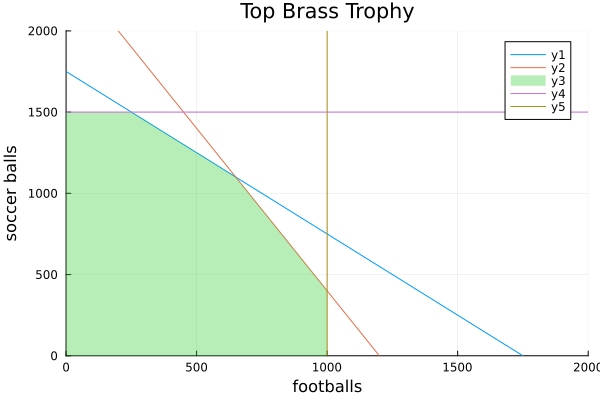

In [2]:
plt = plot()

plot!(plt, x -> 1750 -x, 0, 10000, legend=:topright)
plot!(plt, x -> (4800 - 4x) / 2, 0, 2000)
plot!(plt, x -> min(1750 - x, (4800 - 4x) / 2, 1500), 0, 1000,
    fillrange=0,
    fillcolor=:limegreen,
    fillalpha=0.35,
    linecolor=:transparent
)
hline!(plt, [1500])
vline!(plt, [1000])
xlims!(plt, 0, 2000)
ylims!(plt, 0, 2000)
xlabel!(plt, "footballs")
ylabel!(plt, "soccer balls")
title!(plt, "Top Brass Trophy")
display(plt)

In [3]:
model = Model(HiGHS.Optimizer)

A JuMP Model
├ solver: HiGHS
├ objective_sense: FEASIBILITY_SENSE
├ num_variables: 0
├ num_constraints: 0
└ Names registered in the model: none

In [4]:
@variable(model, 0 <= x <= 1000)
@variable(model, 0 <= y <= 1500)

y

In [5]:
@constraint(model, x + y <= 1750)

x + y ≤ 1750

In [6]:
@constraint(model, 4x + 2y <= 4800)

4 x + 2 y ≤ 4800

In [7]:
@objective(model, Max, 12x + 9y)

12 x + 9 y

In [8]:
print(model)

In [9]:
optimize!(model)

Running HiGHS 1.15.1 (git hash: 04024d701f): Copyright (c) 2026 under MIT licence terms
Includes third-party software components, see THIRD_PARTY_NOTICES.md for full details
Using BLAS: Apple Accelerate 
LP has 2 rows; 2 cols; 4 nonzeros
Coefficient ranges:
  Matrix  [1e+00, 4e+00]
  Cost    [9e+00, 1e+01]
  Bound   [1e+03, 2e+03]
  RHS     [2e+03, 5e+03]
Presolving model
2 rows, 2 cols, 4 nonzeros 0s
2 rows, 2 cols, 4 nonzeros 0s
Presolve reductions: rows 2(-0); columns 2(-0); nonzeros 4(-0) - Not reduced
Problem not reduced by presolve: solving the LP
Using dual simplex solver
  Iteration        Objective     Infeasibilities num(sum)
          0     0.0000000000e+00 Ph1: 0(0) 0.0s
          2     1.7700000000e+04 Pr: 0(0) 0.0s

Model status        : Optimal
Simplex   iterations: 2
Objective value     :  1.7700000000e+04
P-D objective error :  0.0000000000e+00
HiGHS run time      :          0.00


In [10]:
solution_summary(model)

solution_summary(; result = 1, verbose = false)
├ solver_name          : HiGHS
├ Termination
│ ├ termination_status : OPTIMAL
│ ├ result_count       : 1
│ ├ raw_status         : kHighsModelStatusOptimal
│ └ objective_bound    : 1.77000e+04
├ Solution (result = 1)
│ ├ primal_status        : FEASIBLE_POINT
│ ├ dual_status          : FEASIBLE_POINT
│ ├ objective_value      : 1.77000e+04
│ ├ dual_objective_value : 1.77000e+04
│ └ relative_gap         : 0.00000e+00
└ Work counters
  ├ solve_time (sec)   : 8.82416e-04
  ├ simplex_iterations : 2
  ├ barrier_iterations : 0
  └ node_count         : 0

In [11]:
value(x)

650.0

In [12]:
value(y)

1100.0